In [ ]:
# 日本語対応のモジュールをインストールする(その1)
!pip install japanize-matplotlib
# 日本語対応のモジュールをインストールする(その2)
!apt-get install -y fonts-ipafont-gothic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 29.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=bb5572760936b5fbf4d714b78a989747542bae93c5e4e39164ffbe180f87ff36
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-ipafont-mincho
The following NEW packages will be installed:
  fonts-ipafont-gothic fonts-ipafont-mincho
0 upgraded, 2 newly installed, 0 to remove and 2 not upgraded.
Need to get 8,237 kB of archives.
After this operation, 28.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-ipafont-gothic all 00303-21ubuntu1 [3,513 kB]
Get:2 http://ar

In [ ]:
# 各ライブラリーをインポートする
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold, KFold, cross_validate)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#データ読み込み
URL = "https://data.insideairbnb.com/japan/kant%C5%8D/tokyo/2023-06-29/data/listings.csv.gz"
df = pd.read_csv(URL, compression="gzip", low_memory=False)

df["is_superhost"] = (df["host_is_superhost"] == "t").astype(int)
if df["price"].dtype == object:
    df["price"] = df["price"].str.replace(r"[\$,]", "", regex=True).astype(float)

FEATURES = [
    "price", "number_of_reviews", "review_scores_rating",
    "accommodates", "bedrooms", "minimum_nights", "availability_365"
]

df_clean = df[FEATURES + ["is_superhost"]].dropna()

X = df_clean[FEATURES].values
y = df_clean["is_superhost"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
X_sc = scaler.fit_transform(X) # 交差検証用

print(f" ✔データ準備完了: {len(df_clean):,}件")
print(f" SH比率:{y.mean():.1%} 非SH: {1-y.mean():.1%}")
print(f" 訓練: {len(X_train):,} テスト: {len(X_test):,}")

 ✔データ準備完了: 8,181件
 SH比率:29.8% 非SH: 70.2%
 訓練: 6,544 テスト: 1,637


- ベースライン(全員を非SHと予測)―
 正解率: 0.701 ← 非SH比率そのもの
 SH再現率: 0.000 SHを1件も検出できていない
 SH F1 : 0.000

- ロジスティック回帰(標準)——
 正解率: 0.720 ベースライン 0.701 より高い
 SH再現率: 0.260 ベースライン 0.000 より高い

- ロジスティック回帰(class_weight='balanced')—
 正解率: 0.688 ← ベースライン 0.701 より低い
 SH再現率: 0.785 ベースライン 0.000 より高い
 ※正解率はベースライン付近でも、SH再現率は大きく改善する点に注目


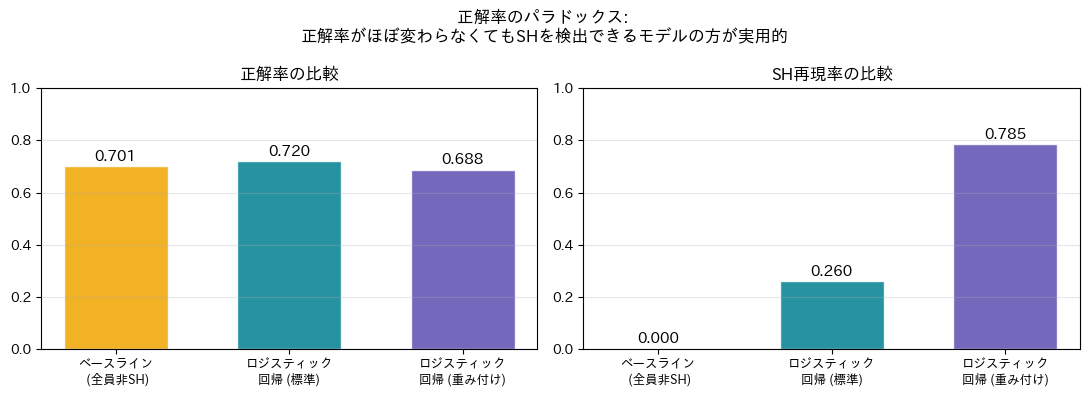

In [ ]:
# - ベースライン:全員を非SH(多数クラス)と予測
y_pred_baseline = np.zeros(len(y_test), dtype=int) #全員(非SH)
baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_rec = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_prec = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)

print("- ベースライン(全員を非SHと予測)―")
print(f" 正解率: {baseline_acc:.3f} ← 非SH比率そのもの")
print(f" SH再現率: {baseline_rec:.3f} SHを1件も検出できていない")
print(f" SH F1 : {baseline_f1:.3f}")

# - ロジスティック回帰 (標準)——
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

lr_acc = accuracy_score(y_test, y_pred_lr)
lr_rec = recall_score(y_test, y_pred_lr, zero_division=0)

# 不均衡対処版(class_weight='balanced')—
# ※パラドックスは「対処を入れると正解率は下がるが再現率が激増する」形で最も鮮明になる
lr_bal = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=42)
lr_bal.fit(X_train_sc, y_train)
y_pred_bal = lr_bal.predict(X_test_sc)

bal_acc = accuracy_score(y_test, y_pred_bal)
bal_rec = recall_score(y_test, y_pred_bal, zero_division=0)

# 比較結果を「高い/低い」 自動判定で表示(直書きしない)
def updown(value, ref):
    """value が ref より高い/低い/同等を日本語で返す"""
    if value > ref + 1e-9:
        return f"ベースライン {ref:.3f} より高い"
    elif value < ref - 1e-9:
        return f"ベースライン {ref:.3f} より低い"
    else:
        return f"ベースライン {ref:.3f} とほぼ同じ"

print("\n- ロジスティック回帰(標準)——")
print(f" 正解率: {lr_acc:.3f} {updown(lr_acc, baseline_acc)}")
print(f" SH再現率: {lr_rec:.3f} {updown(lr_rec, baseline_rec)}")

print("\n- ロジスティック回帰(class_weight='balanced')—")
print(f" 正解率: {bal_acc:.3f} ← {updown(bal_acc, baseline_acc)}")
print(f" SH再現率: {bal_rec:.3f} {updown(bal_rec, baseline_rec)}")
print(" ※正解率はベースライン付近でも、SH再現率は大きく改善する点に注目")

# - 比較グラフ (S3のビジュアルをコードで再現)—
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
models_name = ["ベースライン\n (全員非SH)", "ロジスティック\n回帰 (標準)", "ロジスティック\n回帰 (重み付け)"]
accs = [baseline_acc, lr_acc, bal_acc]
recs = [baseline_rec, lr_rec, bal_rec]
colors_acc = ["#F0A500", "#028090", "#5C4DB1"]
colors_rec = ["#E05252", "#028090", "#5C4DB1"]

for ax, vals, colors, title, ylim in [
    (axes[0], accs, colors_acc, "正解率の比較",(0.0, 1.0)),
    (axes[1], recs, colors_rec, "SH再現率の比較", (0.0, 1.0)),
]:
    bars = ax.bar(models_name, vals, color=colors, alpha=0.85, edgecolor="white", width=0.6)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{v:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=12)
    ax.grid(True, axis="y", alpha=0.3)
    ax.tick_params(axis="x", labelsize=9)

plt.suptitle("正解率のパラドックス: \n正解率がほぼ変わらなくてもSHを検出できるモデルの方が実用的",fontsize=12)
plt.tight_layout()
plt.savefig("accuracy_paradox.png", dpi=150, bbox_inches="tight")
plt.show()

 ロジスティック回帰 (標準)の混同行列—
 TP(本物SHをSHと正解) : 127
 FP (非SHをSHと誤判定) : 97
 FN (SHを非SHと見逃し) : 362  コストが高い!
 TN (非SHを非SHと正解) : 1,051

 正解率 = (TP+TN)/(全体) = (127+1051)/1637 = 0.720
 SH適合率 = TP/(TP+FP) = 127/(127+97) = 0.567
 SH再現率 = TP/(TP+FN) = 127/(127+362) = 0.260


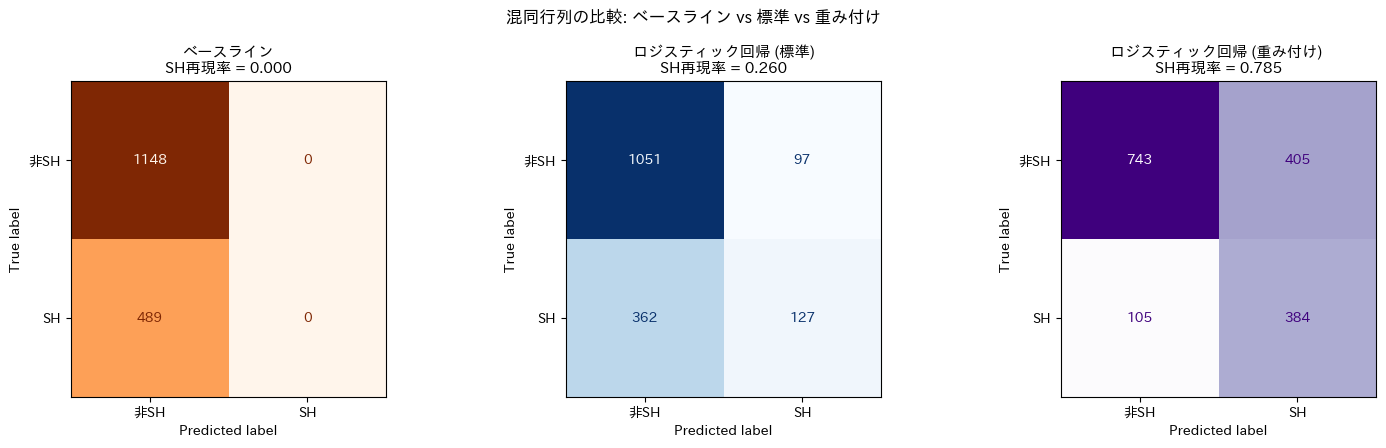

In [ ]:

#混同行列 - TP/FP/FN/TN
cm = confusion_matrix(y_test, y_pred_lr)
tn, fp, fn, tp = cm.ravel()
print(" ロジスティック回帰 (標準)の混同行列—")
print(f" TP(本物SHをSHと正解) : {tp:,}")
print(f" FP (非SHをSHと誤判定) : {fp:,}")
print(f" FN (SHを非SHと見逃し) : {fn:,}  コストが高い!")
print(f" TN (非SHを非SHと正解) : {tn:,}\n")

print(f" 正解率 = (TP+TN)/(全体) = ({tp}+{tn})/{tp+fp+fn+tn} = {(tp+tn)/(tp+fp+fn+tn):.3f}")

# 適合率・再現率は分母が0になり得るのでガード
prec_calc = tp/(tp+fp) if (tp+fp) > 0 else 0.0
rec_calc = tp/(tp+fn) if (tp+fn) > 0 else 0.0

print(f" SH適合率 = TP/(TP+FP) = {tp}/({tp}+{fp}) = {prec_calc:.3f}")
print(f" SH再現率 = TP/(TP+FN) = {tp}/({tp}+{fn}) = {rec_calc:.3f}")

# 混同行列の可視化(ベースライン / LR標準 / LR重み付けの3枚)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
cm_base = confusion_matrix(y_test, y_pred_baseline)

ConfusionMatrixDisplay(cm_base, display_labels=["非SH", "SH"]).plot(cmap="Oranges", ax=axes[0], colorbar=False)
axes[0].set_title(f"ベースライン\nSH再現率 = {baseline_rec:.3f}", fontsize=11)

ConfusionMatrixDisplay(cm, display_labels=["非SH", "SH"]).plot(cmap="Blues", ax=axes[1], colorbar=False)
axes[1].set_title(f"ロジスティック回帰 (標準)\nSH再現率 = {lr_rec:.3f}", fontsize=11)

cm_bal = confusion_matrix(y_test, y_pred_bal)
ConfusionMatrixDisplay(cm_bal, display_labels=["非SH", "SH"]).plot(cmap="Purples", ax=axes[2], colorbar=False)
axes[2].set_title(f"ロジスティック回帰 (重み付け) \nSH再現率 = {bal_rec:.3f}", fontsize=11)

plt.suptitle("混同行列の比較: ベースライン vs 標準 vs 重み付け", fontsize=12)
plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#5つの評価指標を一括確認
probs_lr = lr.predict_proba(X_test_sc)[:, 1]
print("- classification_report (P R F1)—")
print(classification_report(y_test, y_pred_lr, target_names=["非SH", "SH"]))

roc_lr = roc_auc_score(y_test, probs_lr)
pr_lr = average_precision_score(y_test, probs_lr)

print(f"ROC-AUC : {roc_lr:.3f} (ベースライン = 0.500 固定)")
print(f"PR-AUC : {pr_lr:.3f} (ベースライン = SH比率  {y_test.mean():.3f})\n")

print("— 各指標の使い分け  ")
print(" SH適合率(P): SHと予測したものが本当にSHかを確認したいとき")
print(" SH再現率(R):本物SHを取りこぼさないことを優先したいとき")
print(" SH F1 : PとRのバランスをとりたいとき")
print(" ROC-AUC : 均衡データで総合力を評価したいとき")
print(" PR-AUC★ : 不均衡データで少数クラスの検出性能を評価したいとき")

- classification_report (P R F1)—
              precision    recall  f1-score   support

         非SH       0.74      0.92      0.82      1148
          SH       0.57      0.26      0.36       489

    accuracy                           0.72      1637
   macro avg       0.66      0.59      0.59      1637
weighted avg       0.69      0.72      0.68      1637

ROC-AUC : 0.760 (ベースライン = 0.500 固定)
PR-AUC : 0.545 (ベースライン = SH比率  0.299)

— 各指標の使い分け  
 SH適合率(P): SHと予測したものが本当にSHかを確認したいとき
 SH再現率(R):本物SHを取りこぼさないことを優先したいとき
 SH F1 : PとRのバランスをとりたいとき
 ROC-AUC : 均衡データで総合力を評価したいとき
 PR-AUC★ : 不均衡データで少数クラスの検出性能を評価したいとき


- 3つの閾値で指標を比較―
 閾値  SH適合率(P)  SH再現率(R)  SH F1   正解率
0.3     0.489     0.785  0.602 0.690
0.5     0.567     0.260  0.356 0.720
0.7     0.765     0.027  0.051 0.707

F1スコアが最大になる最適閾値: 0.303


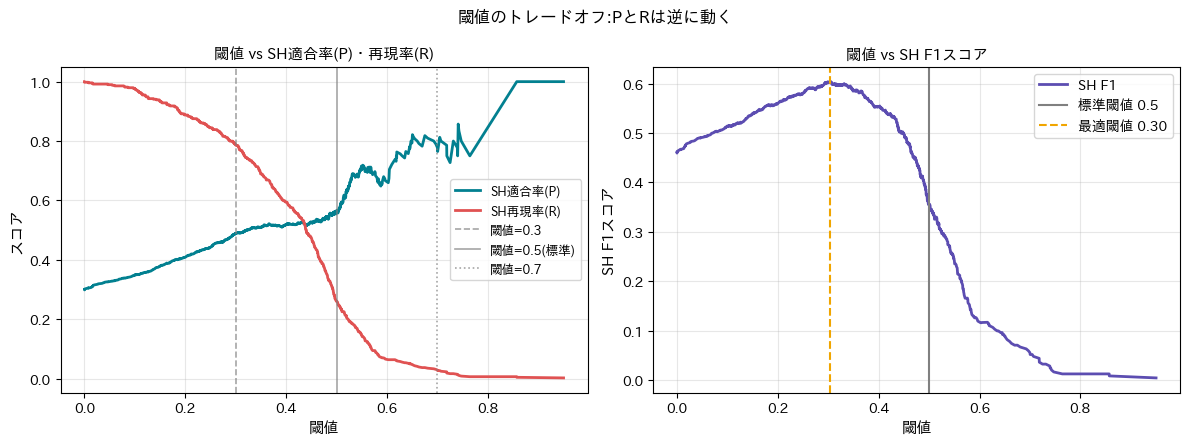

In [ ]:
#閾値のトレードオフ
print("- 3つの閾値で指標を比較―")
thresholds_compare = [0.3, 0.5, 0.7]
rows_thr = []
for thr in thresholds_compare:
    pred_thr = (probs_lr >= thr).astype(int)
    rows_thr.append({
        "閾値": thr,
        "SH適合率(P)": round(precision_score(y_test, pred_thr, zero_division=0), 3),
        "SH再現率(R)": round(recall_score(y_test, pred_thr, zero_division=0), 3),
        "SH F1": round(f1_score(y_test, pred_thr, zero_division=0), 3),
        "正解率": round(accuracy_score(y_test, pred_thr), 3),
    })
print(pd.DataFrame(rows_thr).to_string(index=False))

#最適閾値の計算(F1最大)
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, probs_lr)
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-8)
best_thr = thr_arr[f1_arr.argmax()]
print(f"\nF1スコアが最大になる最適閾値: {best_thr:.3f}")

# 閾値トレードオフのグラフ
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(thr_arr, prec_arr[:-1], color="#028090", linewidth=2, label="SH適合率(P)")
axes[0].plot(thr_arr, rec_arr[:-1], color="#E05252", linewidth=2, label="SH再現率(R)")

for thr, ls, lbl in [(0.3,"--","0.3"), (0.5,"-","0.5(標準)"), (0.7,":", "0.7")]:
    axes[0].axvline(x=thr, color="gray", linestyle=ls, linewidth=1.2, alpha=0.7, label=f"閾値={lbl}")

axes[0].set_xlabel("閾値", fontsize=11)
axes[0].set_ylabel("スコア", fontsize=11)
axes[0].set_title("閾値 vs SH適合率(P)・再現率(R)", fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(thr_arr, f1_arr, color="#5C4DB1", linewidth=2, label="SH F1")
axes[1].axvline(x=0.5, color="gray", linestyle="-", linewidth=1.5, label="標準閾値 0.5")
axes[1].axvline(x=best_thr, color="#F0A500", linestyle="--", linewidth=1.5, label=f"最適閾値 {best_thr:.2f}")

axes[1].set_xlabel("閾値", fontsize=11)
axes[1].set_ylabel("SH F1スコア", fontsize=11)
axes[1].set_title("閾値 vs SH F1スコア", fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle("閾値のトレードオフ:PとRは逆に動く", fontsize=12)
plt.tight_layout()
plt.savefig("threshold_tradeoff.png", dpi=150, bbox_inches="tight")
plt.show()

- ROC-AUC と PR-AUC の一覧 ―
 決定木                ROC-AUC=0.793 PR-AUC=0.614
 ランダムフォレスト          ROC-AUC=0.850 PR-AUC=0.720
 ロジスティック回帰          ROC-AUC=0.760 PR-AUC=0.545
 SVM(線形・重み付け)       ROC-AUC=0.755 PR-AUC=0.526


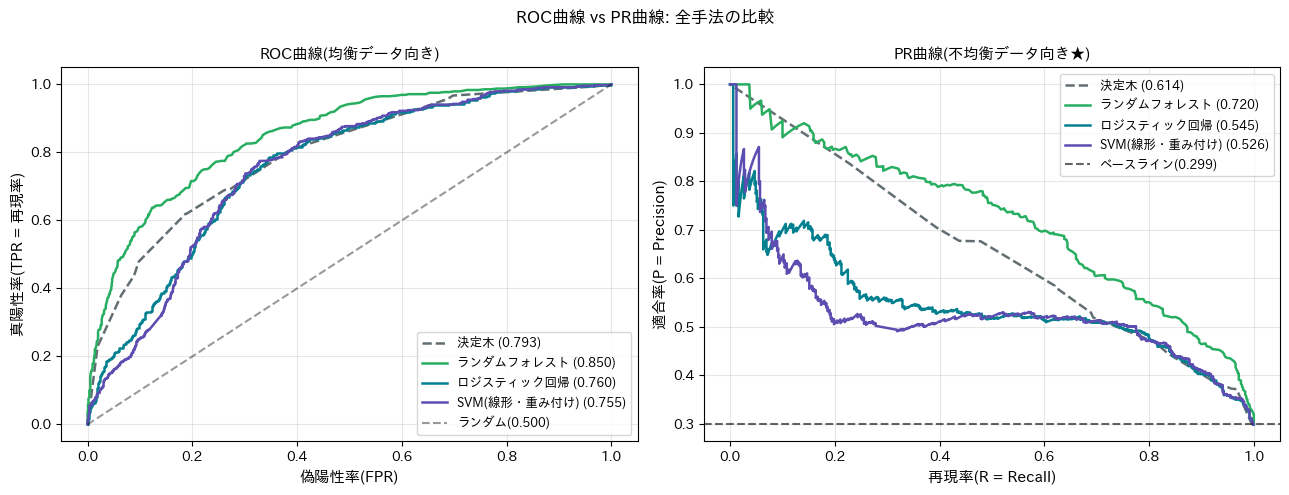

In [ ]:

#第5～7回の主要手法を準備
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
# 不均衡データで多数クラスに倒れるのを防ぐため class_weight='balanced' を付与
svm = SVC(kernel="linear", C=1.0, class_weight="balanced", probability=True, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train_sc, y_train)

models_eval = [
    ("決定木", dt, X_test, "--", "#636E72"),
    ("ランダムフォレスト", rf, X_test, "-", "#27AE60"),
    ("ロジスティック回帰", lr, X_test_sc, "-", "#028090"),
    ("SVM(線形・重み付け)", svm, X_test_sc, "-", "#5C4DB1"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
baseline_pr = y_test.mean()
print("- ROC-AUC と PR-AUC の一覧 ―")

for name, model, X_inp, ls, color in models_eval:
    probs = model.predict_proba(X_inp)[:, 1]
    roc_a = roc_auc_score(y_test, probs)
    pr_a = average_precision_score(y_test, probs)
    print(f" {name:18s} ROC-AUC={roc_a:.3f} PR-AUC={pr_a:.3f}")

    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, color=color, linestyle=ls, linewidth=1.8, label=f"{name} ({roc_a:.3f})")

    p_arr, r_arr, _ = precision_recall_curve(y_test, probs)
    axes[1].plot(r_arr, p_arr, color=color, linestyle=ls, linewidth=1.8, label=f"{name} ({pr_a:.3f})")

axes[0].plot([0,1],[0,1],"k--",alpha=0.4, label="ランダム(0.500)")
axes[0].set_xlabel("偽陽性率(FPR)", fontsize=11)
axes[0].set_ylabel("真陽性率(TPR = 再現率)",fontsize=11)
axes[0].set_title("ROC曲線(均衡データ向き)", fontsize=11)
axes[0].legend(fontsize=9, loc="lower right")
axes[0].grid(True, alpha=0.3)

axes[1].axhline(y=baseline_pr, color="k", linestyle="--", alpha=0.6, label=f"ベースライン({baseline_pr:.3f})")
axes[1].set_xlabel("再現率(R = Recall)", fontsize=11)
axes[1].set_ylabel("適合率(P = Precision)", fontsize=11)
axes[1].set_title("PR曲線(不均衡データ向き★)", fontsize=11)
axes[1].legend(fontsize=9, loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.suptitle("ROC曲線 vs PR曲線: 全手法の比較",fontsize=12)
plt.tight_layout()
plt.savefig("roc_pr_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#クラス重み付け
def metrics(name, model, X_inp, y_true):
    pred = model.predict(X_inp)
    proba = model.predict_proba(X_inp)[:, 1]
    return {
        "手法": name,
        "正解率": round(accuracy_score(y_true, pred), 3),
        "SH適合率P": round(precision_score(y_true, pred, zero_division=0), 3),
        "SH再現率R": round(recall_score(y_true, pred, zero_division=0), 3),
        "SH F1": round(f1_score(y_true, pred, zero_division=0), 3),
        "PR-AUC": round(average_precision_score(y_true, proba), 3),
        "ROC-AUC": round(roc_auc_score(y_true, proba), 3),
    }

cw_df = pd.DataFrame([
    metrics("LR(対処なし)", lr, X_test_sc, y_test),
    metrics("LR(class_weight)", lr_bal, X_test_sc, y_test),
]).set_index("手法")
print(cw_df.to_string())

                    正解率  SH適合率P  SH再現率R  SH F1  PR-AUC  ROC-AUC
手法                                                             
LR(対処なし)          0.720   0.567   0.260  0.356   0.545     0.76
LR(class_weight)  0.688   0.487   0.785  0.601   0.542     0.76


── ➁ SMOTE（少数クラスを増やす ──
 Before : SH=1,953 / 全6,544
 After: SH=4,591 / 全9,182
── ③ アンダーサンプリング(多数クラスを減らす)―
 Before: 非SH=4,591 / 全6,544
 After: 非SH=1,953 / 全3,906
──　4条件の比較　──
                          正解率  SH適合率P  SH再現率R  SH F1  PR-AUC  ROC-AUC
手法                                                                   
①標準(対処なし)               0.720   0.567   0.260  0.356   0.545    0.760
②class_weight=balanced  0.688   0.487   0.785  0.601   0.542    0.760
③SMOTE                  0.684   0.482   0.783  0.597   0.539    0.759
④アンダーサンプリング             0.692   0.490   0.789  0.605   0.545    0.760


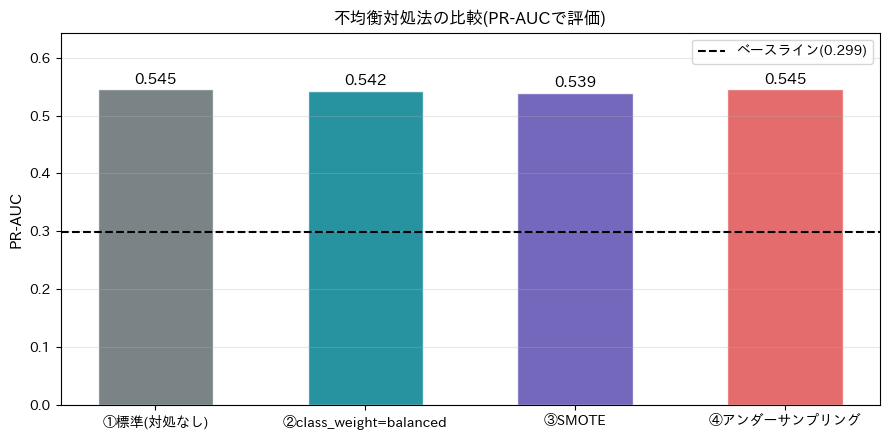

In [ ]:
# リサンプリング
print("── ➁ SMOTE（少数クラスを増やす ──")
sm = SMOTE(random_state=42)
X_sm, y_sm = sm.fit_resample(X_train_sc, y_train)
print(f" Before : SH={y_train.sum():,} / 全{len(y_train):,}")
print(f" After: SH={y_sm.sum():,} / 全{len(y_sm):,}")

lr_smote = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_smote.fit(X_sm, y_sm)

print("── ③ アンダーサンプリング(多数クラスを減らす)―")
rus = RandomUnderSampler(random_state=42)
X_us, y_us = rus.fit_resample(X_train_sc, y_train)
print(f" Before: 非SH={len(y_train)-y_train.sum():,} / 全{len(y_train):,}")
print(f" After: 非SH={len(y_us)-y_us.sum():,} / 全{len(y_us):,}")

lr_under = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
lr_under.fit(X_us, y_us)

print("──　4条件の比較　──")
resamp_df = pd.DataFrame([
    metrics("①標準(対処なし)", lr, X_test_sc, y_test),
    metrics("②class_weight=balanced", lr_bal, X_test_sc, y_test),
    metrics("③SMOTE", lr_smote, X_test_sc, y_test),
    metrics("④アンダーサンプリング", lr_under, X_test_sc, y_test),
]).set_index("手法")
print(resamp_df.to_string())

# PR-AUCで比較グラフ
fig, ax = plt.subplots(figsize=(9, 4.5))
colors_bar = ["#636E72","#028090", "#5C4DB1","#E05252"]
bars = ax.bar(resamp_df.index, resamp_df["PR-AUC"], color=colors_bar, alpha=0.85, edgecolor="white", width=0.55)

ax.axhline(y=baseline_pr, color="black", linestyle="--", linewidth=1.5, label=f"ベースライン({baseline_pr:.3f})")

for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylim(0, max(resamp_df["PR-AUC"])*1.18)
ax.set_ylabel("PR-AUC", fontsize=11)
ax.set_title("不均衡対処法の比較(PR-AUCで評価)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("resampling_pr_auc.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:

# K-Fold vs Stratified K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(" 各Foldのクラス比率(SH比率)—")
for cv_name, cv_obj in [("通常 K-Fold", kf), ("Stratified K-Fold", skf)]:
    ratios = [y[val].mean() for _, val in cv_obj.split(X_sc, y)]
    print(f" {cv_name}: {[round(r,3) for r in ratios]}")
    print(f" 平均={np.mean(ratios):.3f} 標準偏差={np.std(ratios):.4f}\n")

print("- Stratified K-Fold で精度推定  ")
cv_models = {
    "LR(対処なし)": LogisticRegression(C=1.0, max_iter=1000),
    "LR(class_weight)": LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000),
    "RF(class_weight)": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1),
}

cv_results = []
for name, model in cv_models.items():
    sc = cross_validate(model, X_sc, y, cv=skf, scoring=["f1", "average_precision", "roc_auc"], n_jobs=-1)
    cv_results.append({
        "手法": name,
        "F1": f"{sc['test_f1'].mean():.3f}±{sc['test_f1'].std():.3f}",
        "PR-AUC": f"{sc['test_average_precision'].mean():.3f}±{sc['test_average_precision'].std():.3f}",
        "ROC-AUC": f"{sc['test_roc_auc'].mean():.3f}±{sc['test_roc_auc'].std():.3f}",
    })

cv_df = pd.DataFrame(cv_results).set_index("手法")
print(cv_df.to_string())
print("\n(±は5FoldのStd: 小さいほど評価が安定)")

 各Foldのクラス比率(SH比率)—
 通常 K-Fold: [np.float64(0.297), np.float64(0.315), np.float64(0.304), np.float64(0.285), np.float64(0.29)]
 平均=0.298 標準偏差=0.0105

 Stratified K-Fold: [np.float64(0.299), np.float64(0.299), np.float64(0.298), np.float64(0.298), np.float64(0.298)]
 平均=0.298 標準偏差=0.0003

- Stratified K-Fold で精度推定  
                           F1       PR-AUC      ROC-AUC
手法                                                     
LR(対処なし)          0.353±0.015  0.540±0.018  0.756±0.009
LR(class_weight)  0.591±0.008  0.538±0.018  0.755±0.008
RF(class_weight)  0.630±0.016  0.727±0.018  0.852±0.011

(±は5FoldのStd: 小さいほど評価が安定)


                     正解率  SH適合率P  SH再現率R  SH F1  PR-AUC  ROC-AUC
手法                                                              
決定木                0.776   0.676   0.479  0.560   0.614    0.793
ランダムフォレスト          0.804   0.733   0.540  0.622   0.720    0.850
XGBoost            0.787   0.692   0.515  0.591   0.708    0.844
ロジスティック回帰          0.720   0.567   0.260  0.356   0.545    0.760
LR + class_weight  0.688   0.487   0.785  0.601   0.542    0.760
RF + class_weight  0.808   0.748   0.540  0.627   0.727    0.850
LR + SMOTE         0.684   0.482   0.783  0.597   0.539    0.759
アンダーサンプリング         0.692   0.490   0.789  0.605   0.545    0.760
SVM (線形・重み付け)      0.665   0.466   0.822  0.595   0.526    0.755

ベースライン正解率: 0.701
PR-AUCのベースライン: 0.299

PR-AUCランキング(高い順): 
手法
RF + class_weight    0.727
ランダムフォレスト            0.720
XGBoost              0.708
決定木                  0.614
ロジスティック回帰            0.545
アンダーサンプリング           0.545
LR + class_weight    0.542
LR + SMOTE           0.539
SVM (線形

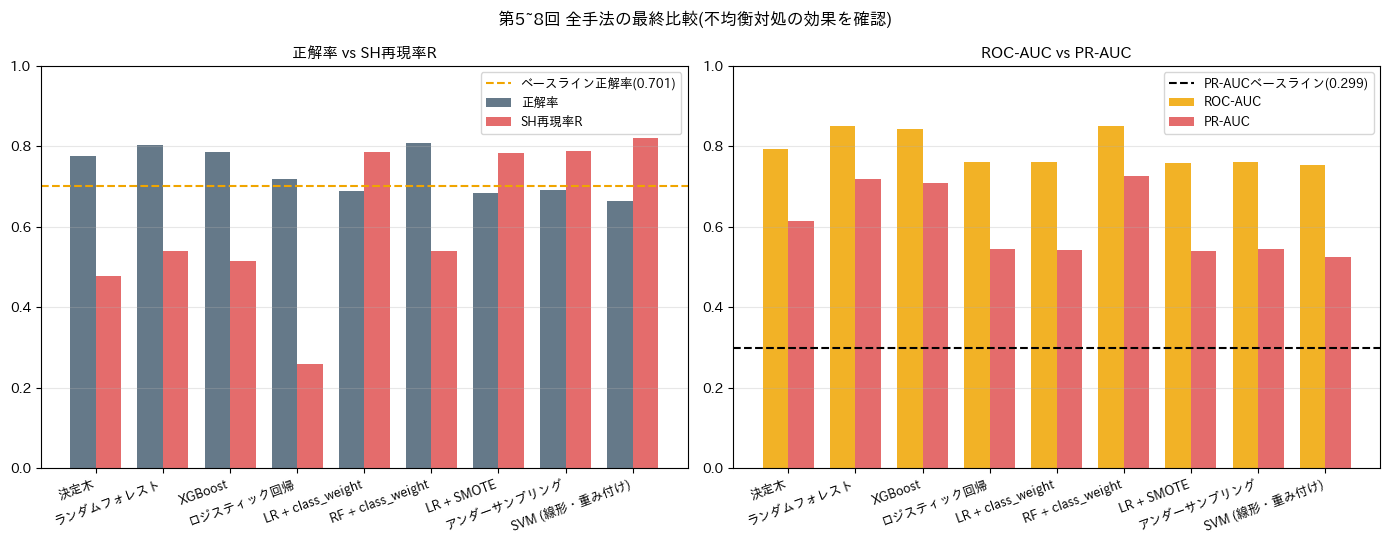

In [ ]:
# 最終比較表
rf_bal = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1)
rf_bal.fit(X_train, y_train)

try:
    import xgboost as xgb
    xgb_m = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, subsample=0.8,
                              eval_metric="logloss", random_state=42, n_jobs=-1, verbosity=0)
    xgb_m.fit(X_train, y_train)
    has_xgb = True
except ImportError:
    has_xgb = False

all_rows = [
    metrics("決定木", dt, X_test, y_test),
    metrics("ランダムフォレスト", rf, X_test, y_test),
    metrics("ロジスティック回帰", lr, X_test_sc, y_test),
    metrics("LR + class_weight", lr_bal, X_test_sc, y_test),
    metrics("RF + class_weight", rf_bal, X_test, y_test),
    metrics("LR + SMOTE", lr_smote, X_test_sc, y_test),
    metrics("アンダーサンプリング", lr_under, X_test_sc, y_test),
    metrics("SVM (線形・重み付け)", svm, X_test_sc, y_test),
]

if has_xgb:
    all_rows.insert(2, metrics("XGBoost", xgb_m, X_test, y_test))

final_df = pd.DataFrame(all_rows).set_index("手法")
print(final_df.to_string())

print(f"\nベースライン正解率: {baseline_acc:.3f}")
print(f"PR-AUCのベースライン: {baseline_pr:.3f}")
print(f"\nPR-AUCランキング(高い順): ")
print(final_df["PR-AUC"].sort_values(ascending=False).to_string())

# 最終比較グラフ
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
x = np.arange(len(final_df))
w = 0.38

axes[0].bar(x-w/2, final_df["正解率"], w, label="正解率", color="#4A6274", alpha=0.85)
axes[0].bar(x+w/2, final_df["SH再現率R"], w, label="SH再現率R", color="#E05252", alpha=0.85)
axes[0].axhline(y=baseline_acc, color="#F0A500", linestyle="--", linewidth=1.5, label=f"ベースライン正解率({baseline_acc:.3f})")
axes[0].set_xticks(x)
axes[0].set_xticklabels(final_df.index, rotation=20, ha="right", fontsize=9)
axes[0].set_ylim(0.0, 1.0)
axes[0].legend(fontsize=9)
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].set_title("正解率 vs SH再現率R", fontsize=11)

axes[1].bar(x-w/2, final_df["ROC-AUC"], w, label="ROC-AUC", color="#F0A500", alpha=0.85)
axes[1].bar(x+w/2, final_df["PR-AUC"], w, label="PR-AUC", color="#E05252", alpha=0.85)
axes[1].axhline(y=baseline_pr, color="black", linestyle="--", linewidth=1.5, label=f"PR-AUCベースライン({baseline_pr:.3f})")
axes[1].set_xticks(x)
axes[1].set_xticklabels(final_df.index, rotation=20, ha="right", fontsize=9)
axes[1].set_ylim(0.0, 1.0)
axes[1].legend(fontsize=9)
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].set_title("ROC-AUC vs PR-AUC", fontsize=11)

plt.suptitle("第5~8回 全手法の最終比較(不均衡対処の効果を確認)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("final_comparison.png", dpi=150, bbox_inches="tight")
plt.show()